# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [9]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [10]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


**1.2:**  How will your solution be used?


**1.3:**  How should success (or failure) be measured?


1.1: The objective of this project is to develop a model that predicts the tax value of properties using the characteristics of the properties themselves. Buisnesses like Zillow often create valuation estimates for properties, which creating a model could greatly help with. From a buisness prespective, this helps create a sense of pricing transparency for both buyers and sellers. 

1.2: We are given a dataset of various numerical and categorical variables. Using these variables, we will be able to construct a predictive model that can accurately assess a properties value based on the available characteristics about the property. In theory, these estimates could be integrated into the Zillow platform itself to improve pricing suggestions for buyers aswell as valuation insights for buyers. 

1.3: The success of this model will be based on its ability to accurately predict property tax values. We can apply metrics we have previously applied earlier in the semester such as Mean Absolute Error (MAE) or Root Mean Squared Error (RSME) or R Suqared values to evaluate our models abilities to do so. A successful model will produce low prediction errors on these tests. 

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [11]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  finishedsqua

In [13]:
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [14]:
df.describe()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,assessmentyear,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
count,7.761300e+04,25007.000000,207.000000,50.000000,77579.000000,77579.000000,15.000000,49809.000000,76963.000000,614.0,...,223.000000,50703.000000,2393.000000,70.000000,77309.000000,17599.000000,77579.0,2900.000000,7.733200e+04,7.757800e+04
mean,1.300781e+07,1.812013,7.386473,679.720000,2.298496,3.053223,3.933333,6.533779,2.316392,66.0,...,6.040359,1.110309,305.460928,216.385714,1968.611507,1.434286,2016.0,14.088276,6.049667e+13,4.901506e+05
std,3.518717e+06,2.965768,2.728030,689.703546,0.996732,1.140480,0.258199,1.722062,0.979689,0.0,...,0.556035,1.169967,238.735241,190.177514,23.793171,0.544515,0.0,2.181281,1.533339e+12,6.537979e+05
min,1.071186e+07,1.000000,2.000000,38.000000,0.000000,0.000000,3.000000,1.000000,1.000000,66.0,...,4.000000,1.000000,11.000000,12.000000,1824.000000,1.000000,2016.0,3.000000,6.037101e+13,1.000000e+03
25%,1.153821e+07,1.000000,7.000000,273.000000,2.000000,2.000000,4.000000,6.000000,2.000000,66.0,...,6.000000,1.000000,170.000000,61.500000,1953.000000,1.000000,2016.0,14.000000,6.037311e+13,2.068985e+05
50%,1.253004e+07,1.000000,7.000000,515.000000,2.000000,3.000000,4.000000,6.000000,2.000000,66.0,...,6.000000,1.000000,250.000000,164.500000,1970.000000,1.000000,2016.0,15.000000,6.037603e+13,3.588785e+05
75%,1.421101e+07,1.000000,7.000000,796.500000,3.000000,4.000000,4.000000,8.000000,3.000000,66.0,...,6.000000,1.000000,364.000000,310.500000,1987.000000,2.000000,2016.0,15.000000,6.059042e+13,5.690000e+05
max,1.676893e+08,13.000000,21.000000,3560.000000,18.000000,16.000000,4.000000,12.000000,18.000000,66.0,...,13.000000,237.000000,3191.000000,868.000000,2016.000000,6.000000,2016.0,99.000000,4.830301e+14,4.906124e+07


In [15]:
missing_percent = df.isnull().mean() * 100
missing_percent

parcelid                         0.000000
airconditioningtypeid           67.779882
architecturalstyletypeid        99.733292
basementsqft                    99.935578
bathroomcnt                      0.043807
bedroomcnt                       0.043807
buildingclasstypeid             99.980673
buildingqualitytypeid           35.823895
calculatedbathnbr                0.837489
decktypeid                      99.208895
finishedfloor1squarefeet        92.221664
calculatedfinishedsquarefeet     0.302784
finishedsquarefeet12             4.754358
finishedsquarefeet13            99.945885
finishedsquarefeet15            96.099880
finishedsquarefeet50            92.221664
finishedsquarefeet6             99.502661
fips                             0.043807
fireplacecnt                    89.320088
fullbathcnt                      0.837489
garagecarcnt                    67.118910
garagetotalsqft                 67.118910
hashottuborspa                  98.017085
heatingorsystemtypeid           36

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

airconditioningtypeid
architecturalstyletypeid
buildingclasstypeid
buildingqualitytypeid
decktypeid
fips
heatingorsystemtypeid
propertylandusetypeid
regionidcity
regionidcounty
regionidneighborhood
regionidzip
storytypeid
typeconstructiontypeid
hashottuborspa
poolcnt
pooltypeid10
pooltypeid2
pooltypeid7
fireplaceflag
taxdelinquencyflag
propertycountylandusecode
propertyzoningdesc

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

- assessmentyear: according to the unique function, there is only 1 assessment year

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

There are several features with over 90% of missing values that should be deleted due to this: 
buildingclasstypeid 99.9% 

finishedsquarefeet13 99.9%

storytypeid 99.9%

basementsqft 99.9% 

yardbuildingsqft26 99.9% 

architecturalstyletypeid 99.7% 

typeconstructiontypeid 99.7% 

fireplaceflag 99.8%

finishedsquarefeet15 96.1%

yardbuildingsqft17 96.9%

taxdelinquencyflag → 96.3%

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

- longitude and latitude: even though location is important, this might be difficult to use meaningfully. \
- propertyzoningdesc: 1900 unique values

There are also a few different columns that give different identifying numbers/codes to a property such as parcelID, censustractandblock, and rawcensustractandblock. These will have a unique ID for each property, and while it is most likely wise to keep at least one, for the purposes of creation of this model, we will likely not need all of these types of variables. 

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

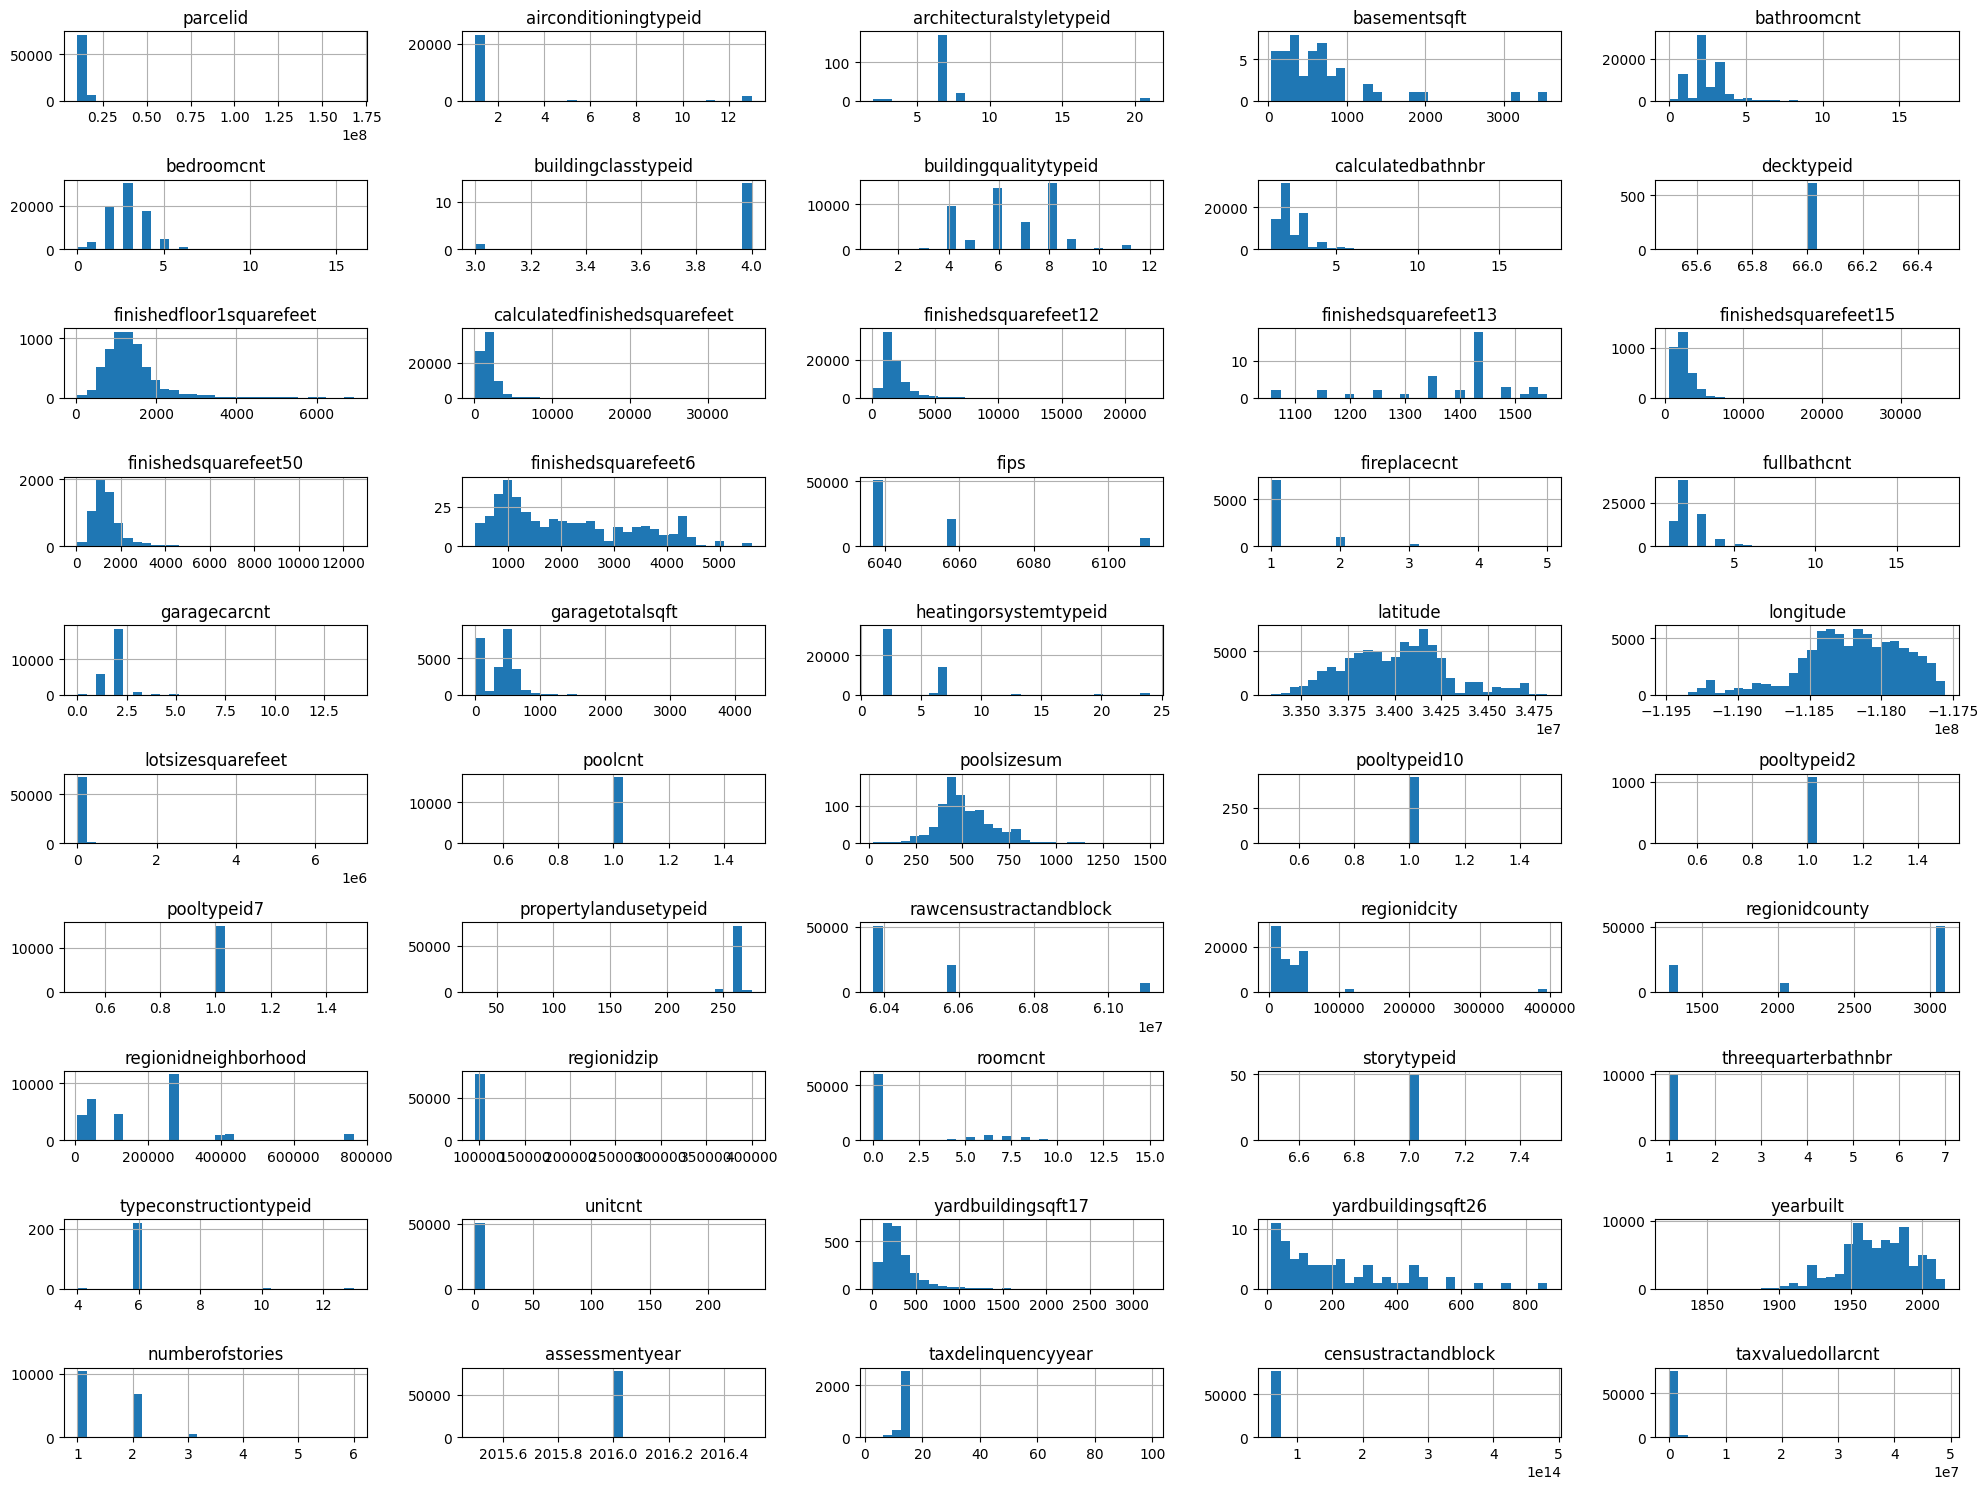

In [17]:
df.hist(figsize=(20, 15), layout=(-1, 5), bins=30)
plt.tight_layout()
plt.show()

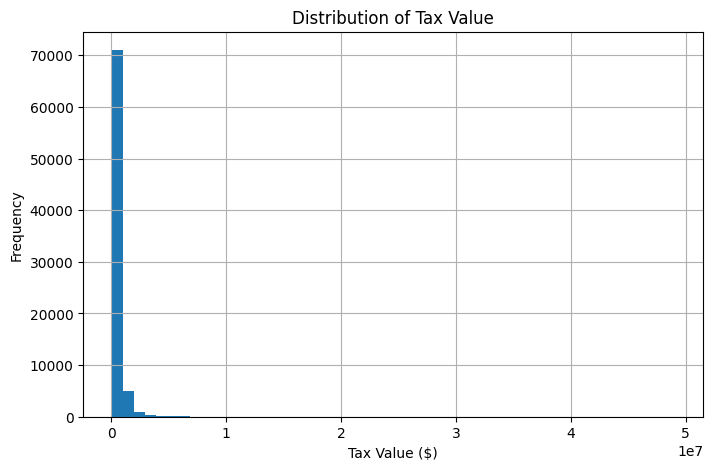

In [24]:
plt.figure(figsize=(8,5))
df['taxvaluedollarcnt'].hist(bins=50)
plt.title("Distribution of Tax Value")
plt.xlabel("Tax Value ($)")
plt.ylabel("Frequency")
plt.show()

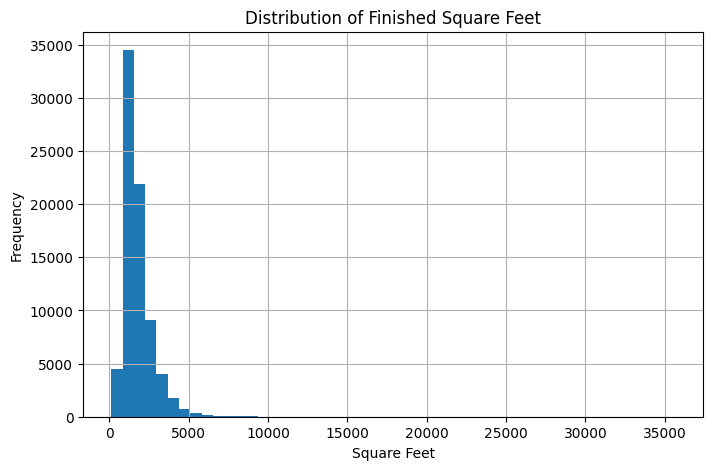

In [25]:
plt.figure(figsize=(8,5))
df['calculatedfinishedsquarefeet'].hist(bins=50)
plt.title("Distribution of Finished Square Feet")
plt.xlabel("Square Feet")
plt.ylabel("Frequency")
plt.show()

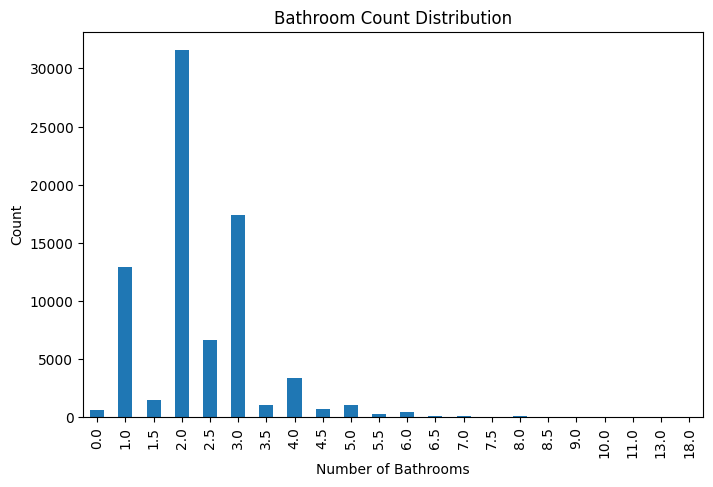

In [26]:
plt.figure(figsize=(8,5))
df['bathroomcnt'].value_counts().sort_index().plot(kind='bar')
plt.title("Bathroom Count Distribution")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")
plt.show()

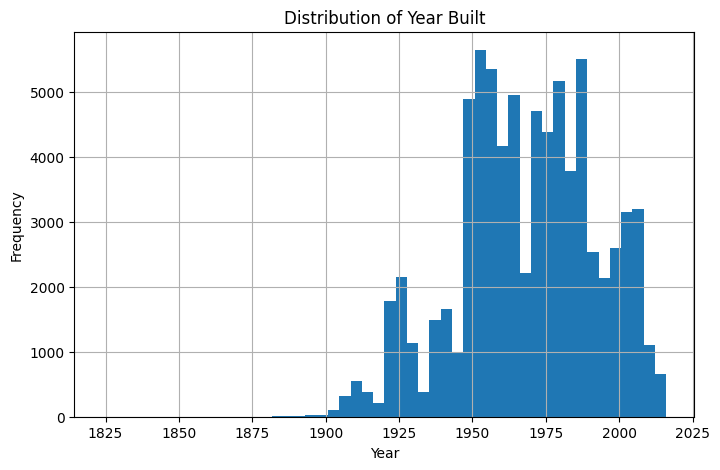

In [27]:
plt.figure(figsize=(8,5))
df['yearbuilt'].hist(bins=50)
plt.title("Distribution of Year Built")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [ ]:
df_clean = df.drop(columns=['parcelid', 'assessmentyear', 'rawcensustractandblock', 
                                   'censustractandblock', 'basementsqft', 'buildingclasstypeid',
                                   'finishedfloor1squarefeet', 'typeconstructiontypeid'])
df_clean = df_clean.drop(columns=['finishedsquarefeet12', 'calculatedbathnbr', 'fullbathcnt'])                                   
df_clean.head()

#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


***From examining the dataset, it was determined that parcelid functions solely as an identifier and does not contribute to predicting the target variable. Additionally, assessmentyear contains only a single year and therefore lacks predictive value. Variables such as rawcensustractandblock and censustractandblock also behave like identifiers rather than informative features. Features including basementsqft and finishedfloor1squarefeet overlap with other square footage columns already in the dataset, while buildingclasstypeid and typeconstructiontypeid describe construction details that have minimal impact on assessed tax value. Lastly, finishedsquarefeet12, calculatedbathnbr, and fullbathcnt were dropped due to redundancy with calculatedfinishedsquarefeet and bathroomcnt respectively.***

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [ ]:
# Drop columns with 50,000+ nulls (65% missing)
null_vals = df_clean.isnull().sum()
drop_cols = null_vals[null_vals >= 50000].index
df_clean = df_clean.drop(columns=drop_cols)

# Drop columns with 20,000-49,999 nulls (26-64% missing)
drop_cols2 = null_vals[(null_vals >= 20000) & (null_vals < 50000)].index
df_clean = df_clean.drop(columns=drop_cols2)

#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [ ]:
df_clean = df_clean.dropna(subset=['taxvaluedollarcnt'])

Q1 = df_clean['taxvaluedollarcnt'].quantile(0.01)
Q3 = df_clean['taxvaluedollarcnt'].quantile(0.99)
df_clean = df_clean[(df_clean['taxvaluedollarcnt'] >= Q1) & (df_clean['taxvaluedollarcnt'] <= Q3)]



#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


***Rows where the target variable taxvaluedollarcnt was null were dropped, as the model cannot train on samples with no known outcome. Additionally, the target was checked for outliers using the 1st and 99th percentiles, and rows outside that range were removed to prevent extreme values from skewing the model.***

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [ ]:
df_clean = df_clean.fillna(df_clean.median(numeric_only= True))
df_clean = df_clean.fillna(df_clean.mode().iloc[0])

#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


***The median was used to fill numeric values because it is robust to outliers. The mode was used to fill categorical values because it fills with the most common values. Forward/backward fill was not elected because the data is not associated with time-series and the rows are individual properties with no meaningful order.***

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [ ]:
encoder = OrdinalEncoder()
df_clean['propertycountylandusecode'] = encoder.fit_transform(df_clean[['propertycountylandusecode']])

## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

In [ ]:
df_clean.corr()

**F Statistic**

In [ ]:
X = df_clean.drop(columns= 'taxvaluedollarcnt')
y = df_clean['taxvaluedollarcnt']
f_scores, p_value = f_regression(X,y)

f_results = pd.DataFrame({'feature': X.columns, 'f_score': f_scores, 'p_value': p_value}).sort_values('f_score', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(f_results['feature'], f_results['f_score'])
plt.xlabel('F-Score')
plt.title('F-Score by Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**After clearing the outliers, the feature relationships became clearer in the F-score analysis.**

**Forward Selection**

In [ ]:
def forward_feature_selection(X, y, model, 
                              scoring='neg_mean_squared_error', 
                              cv = 5, 
                              tol=None,             
                                                     
                                                                                          
                              max_features=None,      
                              n_jobs=-1,
                              verbose=False
                             ):
    selected_features = []                            
    remaining_features = list(X.columns)              
    best_scores = []                                  
    previous_score = float('inf')                     

    
    
    best_feature_set = None                           
    best_score = float('inf')                         
    
    while remaining_features:
        scores = {}                                   
        for feature in remaining_features:
            current_features = selected_features + [feature]
            
            
            cv_score = -cross_val_score(model, X[current_features], y, 
                                        scoring= scoring, cv=cv, n_jobs=n_jobs
                                       ).mean()
            scores[feature] = cv_score

        
        best_feature = min(scores, key=scores.get)
        current_score = scores[best_feature]
            
        
        if tol is not None and previous_score - current_score < tol:
            if verbose:
                print("Stopping early due to minimal improvement.")
            break

        
        selected_features.append(best_feature)
        best_scores.append(current_score)
        remaining_features.remove(best_feature)
        previous_score = current_score

        if verbose:
            print(f"\nFeatures: {selected_features[-3:]}, CV Score (RMSE): {current_score:.4f}")
        
       
        if current_score < best_score:
            best_score = current_score
            best_feature_set = selected_features.copy()
        
        
        if max_features is not None and len(selected_features) >= max_features:
            break

    return (
        selected_features,      
        best_scores,            
        best_feature_set,      
        best_score              
    )

In [ ]:
model = RandomForestRegressor()

selected_features, best_scores, best_forward_features, best_score = (
    forward_feature_selection(X, y, model, scoring='neg_root_mean_squared_error', verbose=True, max_features=10))

index = np.argmax(np.array(selected_features) == best_forward_features[-1])

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_scores) + 1), best_scores, marker='.')
plt.plot([index+1], best_score, marker='x', color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=90, ha='right', fontsize=7)
plt.title('Forward Feature Selection and CV Scores')
plt.xlabel('Features Added')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()

print(f"Best Features: {best_forward_features}")
print(f"Best CV (RMSE) Score: {best_score:.4f}")

**Backward Selection**

In [ ]:
def backward_feature_selection(X, y, model, 
                               scoring='neg_mean_squared_error', 
                               cv=5, 
                               tol=None,               
                               max_features=None,      
                               n_jobs=-1,
                               verbose=True):
    
    def cv_score(features):
        return -cross_val_score(model, X[features], y, 
                                scoring=scoring, cv=cv, 
                                n_jobs=n_jobs).mean()
    
    features_remaining = list(X.columns)
    initial_score = cv_score(features_remaining)
    best_score = initial_score                
    best_feature_set = features_remaining.copy()    
    selected_features = ['NONE']                     
    best_scores = [initial_score]             
    
    if verbose:
        print("Start with full set of features:")
        print(f'{features_remaining}  CV score (RMSE): {np.around(initial_score, 4)}\n')
    
    target_feature_count = 1 if max_features is None else max_features
    prev_score = initial_score
    round_num = 1
    
    while len(features_remaining) > target_feature_count:
        if verbose:
            print(f'Round {round_num}:')
        
        lowest_score = float('inf')
        feature_to_remove = None
        best_new_features = None
        
        for feature in features_remaining:
            new_feature_set = features_remaining.copy()
            new_feature_set.remove(feature)
            new_score = cv_score(new_feature_set)
            
            if verbose:
                print('Trying removal of:', feature, np.around(new_score, 4))
            
            if new_score < lowest_score:
                lowest_score = new_score
                feature_to_remove = feature
                best_new_features = new_feature_set
        
        if tol is not None and (prev_score - lowest_score) < tol:
            if verbose:
                print("\nStopping early due to minimal improvement.")
            break
        
        if lowest_score < best_score:
            best_score = lowest_score
            best_feature_set = best_new_features.copy()
        
        prev_score = lowest_score
        features_remaining = best_new_features
        selected_features.append(feature_to_remove)
        best_scores.append(lowest_score)
        
        if verbose:
            print(f'\nRemoving {feature_to_remove}:  CV score (RMSE) {np.around(lowest_score, 4)}\n')
        
        round_num += 1
    
    return (
        selected_features,      
        best_scores,            
        best_feature_set,       
        best_score              
    )

In [ ]:
model = GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=random_state)

selected_features, best_scores, best_backward_features, best_score = (
    backward_feature_selection(X, y, model, scoring='neg_root_mean_squared_error', verbose=True, max_features=10))

index = np.argmax(np.array(selected_features) == best_backward_features[-1])
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_scores) + 1), best_scores, marker='.')
plt.plot([index+1], best_score, marker='x', color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=90, ha='right', fontsize=7)
plt.title('Backward Feature Selection (Gradient Boosting) and CV Scores')
plt.xlabel('Features Removed')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()
print(f"Best Features: {best_backward_features}")
print(f"Best CV (RMSE) Score: {best_score:.4f}")

***F-scores and correlation both identify calculatedfinishedsquarefeet as the strongest predictor of tax value, followed by bathroomcnt, bedroomcnt, yearbuilt, and latitude. The forward selection using Random Forest identified regionidzip, bathroomcnt, and calculatedfinishedsquarefeet among its top features, while backward selection using Gradient Boosting retained bathroomcnt, calculatedfinishedsquarefeet, yearbuilt, and latitude in its best feature set. The methods generally agree that calculatedfinishedsquarefeet and bathroomcnt are the most important features, though the selection algorithms also highlighted the value of location-based features like regionidzip and latitude that showed weaker linear correlations but contribute meaningfully to nonlinear models.***

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df_clean['calculatedfinishedsquarefeet'], df_clean['taxvaluedollarcnt'], alpha=0.3, s=5)
axes[0].set_xlabel('Calculated Finished Sq Ft')
axes[0].set_ylabel('Tax Value')
axes[0].set_title('Sq Ft vs Tax Value')

axes[1].scatter(df_clean['bathroomcnt'], df_clean['calculatedfinishedsquarefeet'], alpha=0.3, s=5)
axes[1].set_xlabel('Bathroom Count')
axes[1].set_ylabel('Calculated Finished Sq Ft')
axes[1].set_title('Bathrooms vs Sq Ft')

axes[2].scatter(df_clean['yearbuilt'], df_clean['taxvaluedollarcnt'], alpha=0.3, s=5)
axes[2].set_xlabel('Year Built')
axes[2].set_ylabel('Tax Value')
axes[2].set_title('Year Built vs Tax Value')

plt.tight_layout()
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


- **Sq Ft vs Tax Value:** Tax value generally increases with square footage, showing a clear positive relationship. Most properties are under 5,000 sq ft and $500K, with a few high-value outliers exceeding $2.5M.

- **Bathrooms vs Sq Ft:** Square footage tends to rise with the number of bathrooms, as expected. Most homes have 1–4 bathrooms, though a few extreme outliers exceed 30,000 sq ft.

- **Year Built vs Tax Value:** While most properties were built after 1950, newer homes show a wide range of tax values. Older homes cluster at lower values, indicating that age alone isn’t a strong predictor of value.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

